TASK 1 : WEATHER DATASET

In [54]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier

In [55]:
# Predictor variables
Outlook = ['Rainy','Rainy','Overcast','Sunny','Sunny','Sunny','Overcast',
           'Rainy','Rainy','Sunny','Rainy','Overcast','Overcast','Sunny']

Temperature = ['Hot','Hot','Hot','Mild','Cool','Cool','Cool',
               'Mild','Cool','Mild','Mild','Mild','Hot','Mild']

Humidity = ['High','High','High','High','Normal','Normal','Normal',
            'High','Normal','Normal','Normal','High','Normal','High']

Wind = ['False','True','False','False','False','True','True',
        'False','False','False','True','True','False','True']

In [56]:
# Target variable
Play = ['No','No','Yes','Yes','Yes','No','Yes','No',
        'Yes','Yes','Yes','Yes','Yes','No']

In [57]:
# Label Encoding
le = LabelEncoder()

Outlook_enc = le.fit_transform(Outlook)
Temperature_enc = le.fit_transform(Temperature)
Humidity_enc = le.fit_transform(Humidity)
Wind_enc = le.fit_transform(Wind)
Play_enc = le.fit_transform(Play)

In [58]:
# Combine features
X = list(zip(Outlook_enc, Temperature_enc, Humidity_enc, Wind_enc))
y = Play_enc

In [59]:
# Train-Test Split (95% - 5%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.05, random_state=34
)

In [60]:
# Decision Tree Classifier (Entropy)
clf = DecisionTreeClassifier(
    criterion="entropy",
    max_leaf_nodes=30,
    random_state=34
)

In [61]:
# Train Model
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_leaf_nodes=30, random_state=34)

In [62]:
# Prediction
y_pred = clf.predict(X_test)

In [63]:
# Evaluation
print("Task-1 Accuracy:", accuracy_score(y_test, y_pred))
print("Task-1 Precision:", precision_score(y_test, y_pred))
print("Task-1 Recall:", recall_score(y_test, y_pred))

Task-1 Accuracy: 1.0
Task-1 Precision: 0.0
Task-1 Recall: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [64]:
# Predict given inputs (Exercise Q1 & Q2)
# Rainy, Mild, Normal, False
sample1 = clf.predict([[1, 2, 1, 0]])
print("Prediction for Sample 1 (Rainy,Mild,Normal,False):", sample1)

# Sunny, Cool, High, True
sample2 = clf.predict([[2, 0, 0, 1]])
print("Prediction for Sample 2 (Sunny,Cool,High,True):", sample2)

Prediction for Sample 1 (Rainy,Mild,Normal,False): [1]
Prediction for Sample 2 (Sunny,Cool,High,True): [0]


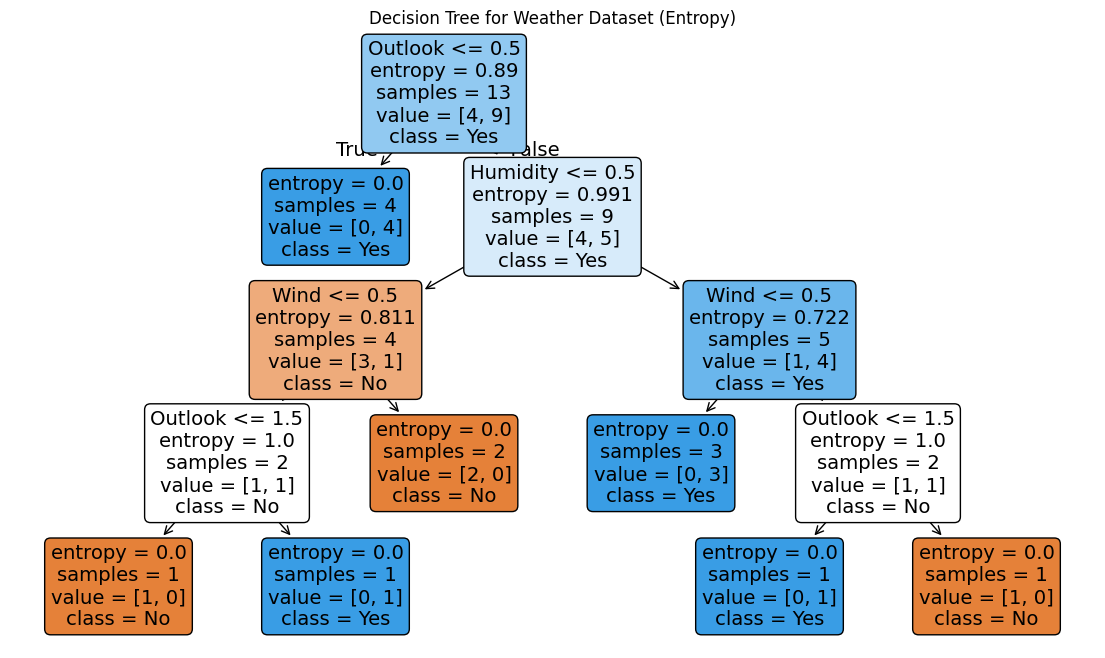

In [65]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
plot_tree(
    clf,
    feature_names=['Outlook', 'Temperature', 'Humidity', 'Wind'],
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True
)
plt.title("Decision Tree for Weather Dataset (Entropy)")
plt.show()

Step-1: Get CCP Alpha Path

In [66]:
# Cost Complexity Pruning Path
path = clf.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas
impurities = path.impurities

print("CCP Alphas:", ccp_alphas)

CCP Alphas: [0.         0.12481202 0.13883233 0.15884089 0.20436206]


Step-2: Train Trees for Each Alpha

In [67]:
clfs = []

for alpha in ccp_alphas:
    dt = DecisionTreeClassifier(
        criterion="entropy",
        random_state=34,
        ccp_alpha=alpha
    )
    dt.fit(X_train, y_train)
    clfs.append(dt)

Step-3: Analyze Tree Size Reduction

In [68]:
node_counts = [dt.tree_.node_count for dt in clfs]
depths = [dt.tree_.max_depth for dt in clfs]

Step-4: Plot Alpha vs Tree Complexity

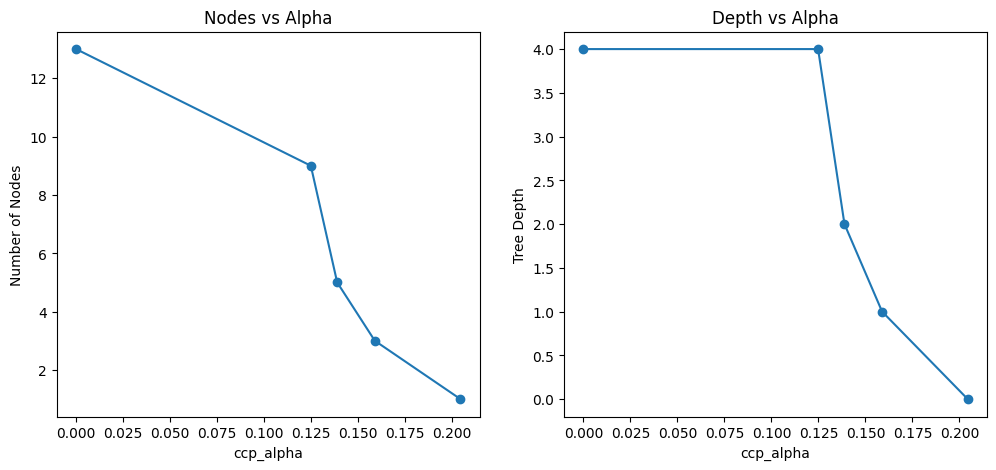

In [69]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(ccp_alphas, node_counts, marker='o')
plt.xlabel("ccp_alpha")
plt.ylabel("Number of Nodes")
plt.title("Nodes vs Alpha")

plt.subplot(1,2,2)
plt.plot(ccp_alphas, depths, marker='o')
plt.xlabel("ccp_alpha")
plt.ylabel("Tree Depth")
plt.title("Depth vs Alpha")

plt.show()

Step-5: Accuracy vs Alpha

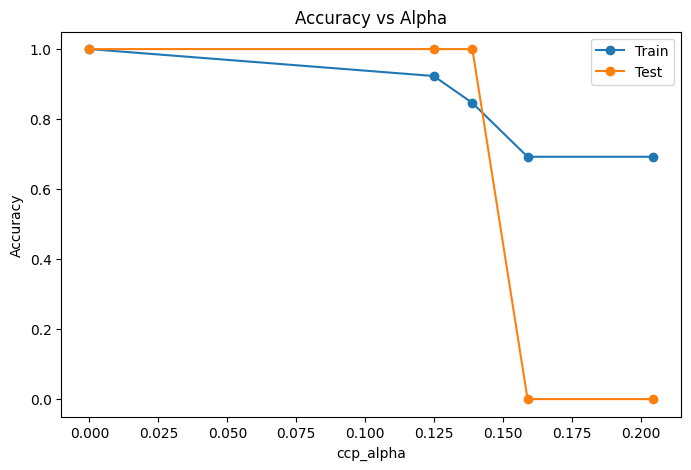

In [70]:
train_scores = [dt.score(X_train, y_train) for dt in clfs]
test_scores = [dt.score(X_test, y_test) for dt in clfs]

plt.figure(figsize=(8,5))
plt.plot(ccp_alphas, train_scores, marker='o', label='Train')
plt.plot(ccp_alphas, test_scores, marker='o', label='Test')
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Alpha")
plt.legend()
plt.show()

Step-6: Choose Best Alpha and Retrain

In [71]:
optimal_alpha = ccp_alphas[test_scores.index(max(test_scores))]
print("Optimal ccp_alpha:", optimal_alpha)

pruned_clf = DecisionTreeClassifier(
    criterion="entropy",
    random_state=34,
    ccp_alpha=optimal_alpha
)

pruned_clf.fit(X_train, y_train)

Optimal ccp_alpha: 0.0


DecisionTreeClassifier(ccp_alpha=np.float64(0.0), criterion='entropy',
                       random_state=34)

Step-7: Plot Pruned Tree

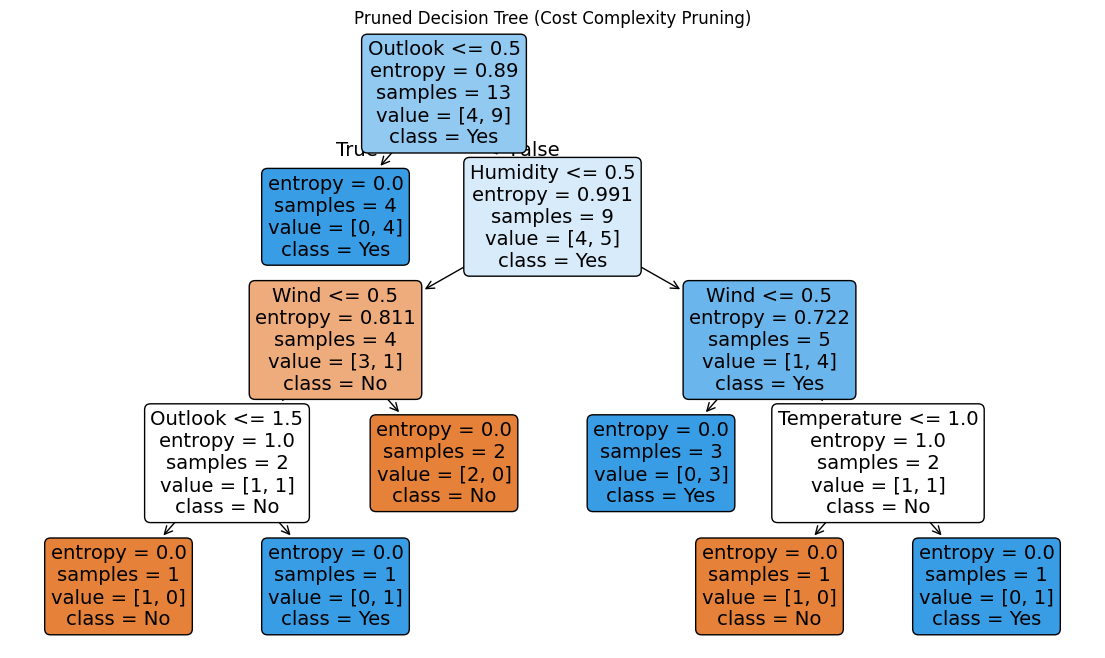

In [72]:
from sklearn.tree import plot_tree

plt.figure(figsize=(14,8))
plot_tree(
    pruned_clf,
    feature_names=['Outlook','Temperature','Humidity','Wind'],
    class_names=['No','Yes'],
    filled=True,
    rounded=True
)
plt.title("Pruned Decision Tree (Cost Complexity Pruning)")
plt.show()

Metric Comparison

In [73]:
# Unpruned Decision Tree
unpruned_clf = DecisionTreeClassifier(
    criterion="entropy",
    random_state=34,
    ccp_alpha=0.0
)

unpruned_clf.fit(X_train, y_train)

y_train_pred_un = unpruned_clf.predict(X_train)
y_test_pred_un = unpruned_clf.predict(X_test)
# Pruned Decision Tree (Using Optimal Alpha)
pruned_clf = DecisionTreeClassifier(
    criterion="entropy",
    random_state=34,
    ccp_alpha=optimal_alpha
)

pruned_clf.fit(X_train, y_train)

y_train_pred_pr = pruned_clf.predict(X_train)
y_test_pred_pr = pruned_clf.predict(X_test)
print("UNPRUNED TREE")
print("Train Accuracy:", accuracy_score(y_train, y_train_pred_un))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_un))
print("Depth:", unpruned_clf.tree_.max_depth)
print("Nodes:", unpruned_clf.tree_.node_count)

print("\nPRUNED TREE")
print("Train Accuracy:", accuracy_score(y_train, y_train_pred_pr))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_pr))
print("Depth:", pruned_clf.tree_.max_depth)
print("Nodes:", pruned_clf.tree_.node_count)

UNPRUNED TREE
Train Accuracy: 1.0
Test Accuracy: 1.0
Depth: 4
Nodes: 13

PRUNED TREE
Train Accuracy: 1.0
Test Accuracy: 1.0
Depth: 4
Nodes: 13


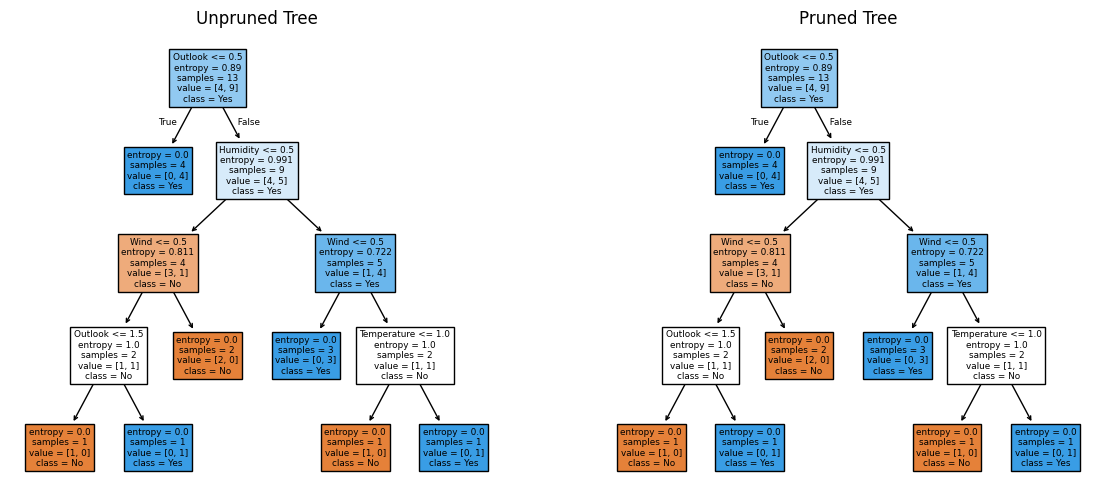

In [74]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plot_tree(unpruned_clf,
          feature_names=['Outlook','Temperature','Humidity','Wind'],
          class_names=['No','Yes'],
          filled=True)
plt.title("Unpruned Tree")

plt.subplot(1,2,2)
plot_tree(pruned_clf,
          feature_names=['Outlook','Temperature','Humidity','Wind'],
          class_names=['No','Yes'],
          filled=True)
plt.title("Pruned Tree")

plt.show()